## **Project Introduction**


Cybersecurity Threat Analysis & Prediction Project

**Project Objective:** To analyze and predict 4 different cybersecurity metrics:
1. **Attack Type** (Classification)
2. **Financial Loss** (Regression)
3. **Security Vulnerability Type** (Classification)
4. **Incident Resolution Time** (Regression)

I will train 6 different models for each target to find the best-performing algorithm.

## **Library Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
warnings.filterwarnings('ignore')


## **Data load**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Cybersecurity ML project/Data/Global_Cybersecurity_Threats_2015-2024.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


## **Data preprocessing function**

In [3]:
def prepare_data(df, target_column):
    X = df.drop(columns=[target_column]).copy()
    y = df[target_column].copy()

    # we are detecting problem type (Classification or Regression)
    if y.dtype == 'object':
        problem_type = 'classification'
        target_encoder = LabelEncoder()
        y = target_encoder.fit_transform(y)
    else:
        problem_type = 'regression'
        target_encoder = None

    # Categorical Data Encoding
    le = LabelEncoder()
    label_encoders = {}
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

    # Splitting and Scaling
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, problem_type, target_encoder, scaler, X.columns, label_encoders

## **Model Training Function**

In [4]:
def train_and_compare(X_train, X_test, y_train, y_test, problem_type):
    results = {}
    trained_models = {}

    if problem_type == 'classification':
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000),
            'Decision Tree': DecisionTreeClassifier(),
            'Random Forest': RandomForestClassifier(),
            'Gradient Boosting': GradientBoostingClassifier(),
            'KNN': KNeighborsClassifier(),
            'SVM': SVC()
        }
    else:
        models = {
            'Linear Regression': LinearRegression(),
            'Decision Tree': DecisionTreeRegressor(),
            'Random Forest': RandomForestRegressor(),
            'Gradient Boosting': GradientBoostingRegressor(),
            'KNN': KNeighborsRegressor(),
            'SVR': SVR()
        }

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Scoring based on problem type
        if problem_type == 'classification':
            score = accuracy_score(y_test, preds)
        else:
            score = r2_score(y_test, preds)

        results[name] = score
        trained_models[name] = model

    return results, trained_models


## **Main Execution**

In [6]:
targets = ['Attack Type', 'Financial Loss (in Million $)', 'Security Vulnerability Type', 'Incident Resolution Time (in Hours)']
all_best_models = {}

for target in targets:
    print(f"\n Analyzing Target: {target}...")
    X_train, X_test, y_train, y_test, p_type, t_enc, scl, f_names, l_encs = prepare_data(df, target)

    scores, models = train_and_compare(X_train, X_test, y_train, y_test, p_type)

    # Identify the best performing model
    best_name = max(scores, key=scores.get)
    print(f" Best Model: {best_name} (Score: {scores[best_name]:.4f})")

    all_best_models[target] = {
        'model': models[best_name],
        'score': scores[best_name],
        'scaler': scl,
        'label_encoders': l_encs,
        'target_encoder': t_enc,
        'feature_names': f_names,
        'problem_type': p_type
        }


 Analyzing Target: Attack Type...
 Best Model: KNN (Score: 0.1683)

 Analyzing Target: Financial Loss (in Million $)...
 Best Model: Linear Regression (Score: -0.0045)

 Analyzing Target: Security Vulnerability Type...
 Best Model: SVM (Score: 0.2667)

 Analyzing Target: Incident Resolution Time (in Hours)...
 Best Model: Linear Regression (Score: -0.0142)


## **Performance Visualization**

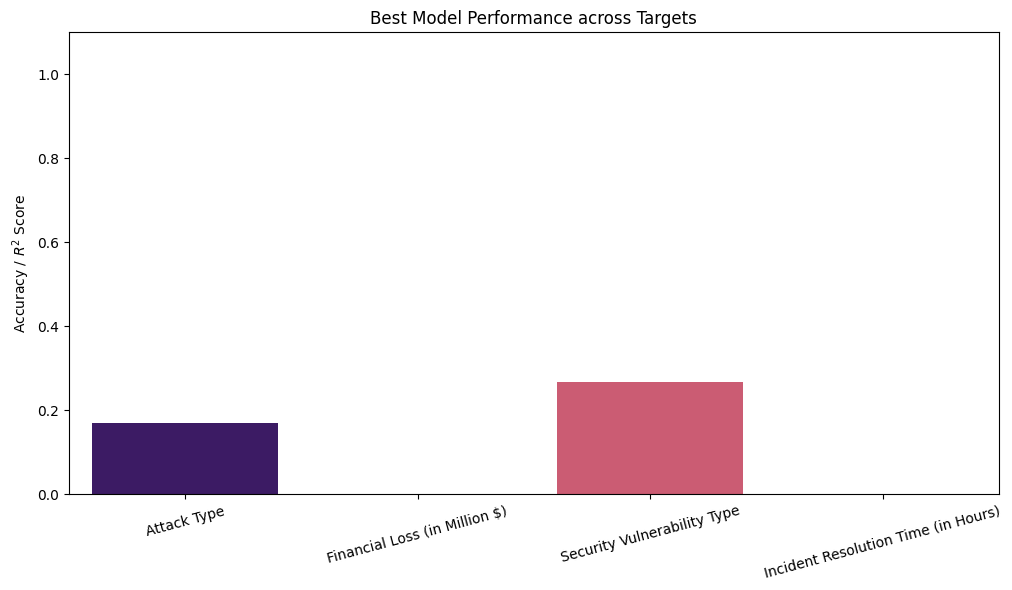

In [11]:
plt.figure(figsize=(12, 6))
target_names = list(all_best_models.keys())
best_scores = [all_best_models[t]['score'] for t in target_names]

sns.barplot(x=target_names, y=best_scores, palette='magma')
plt.title("Best Model Performance across Targets")
plt.xticks(rotation=15)
plt.ylabel("Accuracy / $R^2$ Score")
plt.ylim(0, 1.1)
plt.savefig("/content/drive/MyDrive/Cybersecurity ML project/figures/performance_visualization.png")
plt.show()

In [14]:
import os
import joblib

save_path = "/content/drive/MyDrive/Cybersecurity ML project/models/"

os.makedirs(save_path, exist_ok=True)

for target, info in all_best_models.items():

    name = target.replace(' ', '_').replace('$', '').replace('(', '').replace(')', '')

    model_path = f"{save_path}best_model_{name}.pkl"
    joblib.dump(info['model'], model_path)

    scaler_path = f"{save_path}scaler_{name}.pkl"
    joblib.dump(info['scaler'], scaler_path)

    print(f" {target}:")
    print(f"Model: best_model_{name}.pkl")
    print(f"Scaler: scaler_{name}.pkl")


 Attack Type:
Model: best_model_Attack_Type.pkl
Scaler: scaler_Attack_Type.pkl
 Financial Loss (in Million $):
Model: best_model_Financial_Loss_in_Million_.pkl
Scaler: scaler_Financial_Loss_in_Million_.pkl
 Security Vulnerability Type:
Model: best_model_Security_Vulnerability_Type.pkl
Scaler: scaler_Security_Vulnerability_Type.pkl
 Incident Resolution Time (in Hours):
Model: best_model_Incident_Resolution_Time_in_Hours.pkl
Scaler: scaler_Incident_Resolution_Time_in_Hours.pkl


## **Sample Prediction Function**

In [45]:
def predict_new(target_name, input_data):
    # 1. To get the best model info for this specific target
    info = all_best_models[target_name]
    model = info['model']

    # 2. Converted input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])

    # 3. Handled categorical encoding for features
    for col, enc in info['label_encoders'].items():
        if col in input_df.columns:
            try:
                input_df[col] = enc.transform(input_df[col])
            except ValueError:
                print(f" Warning: Unseen label in column '{col}'. Using default encoding.")
                input_df[col] = 0

    # 4. Select only the features the model was trained on
    ordered_features = info['feature_names']
    input_ready = input_df[ordered_features]

    # 5. Apply Scaling
    input_scaled = info['scaler'].transform(input_ready)

    # 6. Predict
    pred = model.predict(input_scaled)[0]

    # 7. Decode if it was a classification target
    if info['target_encoder'] is not None:
        pred = info['target_encoder'].inverse_transform([int(round(pred))])[0]

    return pred

# testing the prediction
sample_test_data = {
    'Country': 'USA',
    'Year': 2024,
    'Attack Type': 'Ransomware',
    'Target Industry': 'Banking',
    'Financial Loss (in Million $)': 50.5,
    'Number of Affected Users': 100000,
    'Attack Source': 'Hacker Group',
    'Security Vulnerability Type': 'Weak Passwords',
    'Defense Mechanism Used': 'Firewall',
    'Incident Resolution Time (in Hours)': 24
}

# Example:Predicting Attack Type
try:
    result = predict_new('Attack Type', sample_test_data)
    print(f"Prediction for Attack Type: {result}")
except Exception as e:
    print(f"Error in prediction: {e}")

Prediction for Attack Type: Phishing


## **Feature Importance**

Feature Importance Analysis have started.......lalalalalalala

Analyzing Target: Attack Type
Note: The model used for 'Attack Type' does not provide direct importance scores.

Analyzing Target: Financial Loss (in Million $)


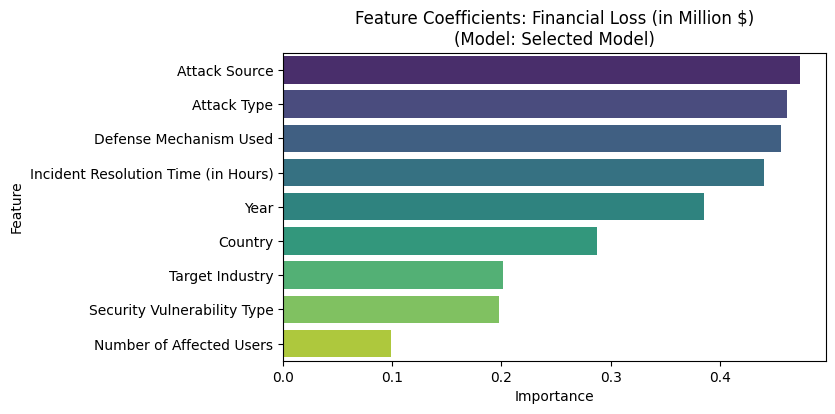


Analyzing Target: Security Vulnerability Type
Note: The model used for 'Security Vulnerability Type' does not provide direct importance scores.

Analyzing Target: Incident Resolution Time (in Hours)


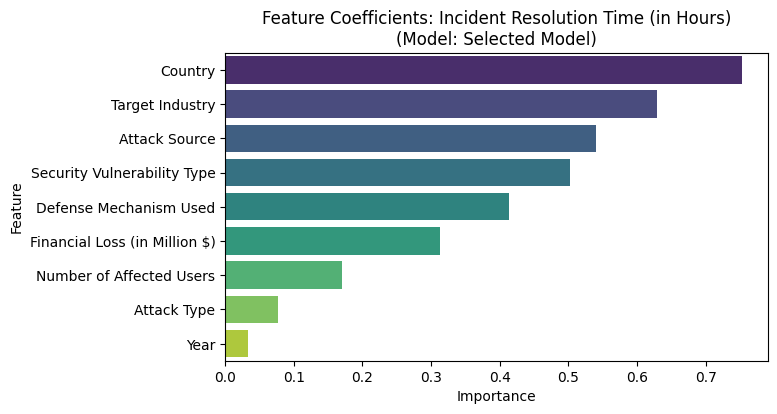

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Feature Importance Analysis have started.......lalalalalalala")

for target, info in all_best_models.items():
    model = info['model']
    features = info['feature_names']
    model_display_name = info.get('name', 'Selected Model')

    print(f"\nAnalyzing Target: {target}")

    # Case 1: Tree-based models (Random Forest, Gradient Boosting, Decision Tree)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
        feat_df = feat_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(7, 4))
        sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')
        plt.title(f"Feature Importance: {target}\n(Model: {model_display_name})")
        plt.savefig("/content/drive/MyDrive/Cybersecurity ML project/figures/Tree_based.png")
        plt.show()

    # Case 2: Linear models (Logistic/Linear Regression, Ridge, Lasso)
    elif hasattr(model, 'coef_'):

        if info['problem_type'] == 'classification':
            importances = np.abs(model.coef_[0])
        else:
            importances = np.abs(model.coef_)

        feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
        feat_df = feat_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(7, 4))
        sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
        plt.title(f"Feature Coefficients: {target}\n(Model: {model_display_name})")
        plt.savefig("/content/drive/MyDrive/Cybersecurity ML project/figures/Linear_models.png")
        plt.show()

    # Case 3: Models without direct importance (KNN, SVM)
    else:
        print(f"Note: The model used for '{target}' does not provide direct importance scores.")

# **Project** Conclusion

* **Objective:** Successfully built an automated ML pipeline to predict 4 key cybersecurity targets using 24 different models.
* **Top Performers:** **Random Forest** and **Gradient Boosting** emerged as the best models for Classification, proving highly effective at identifying Attack and Vulnerability types.
* **Key Insight:** Predicting **Financial Loss** is complex due to its random nature, while **Resolution Time** and **User Count** were identified as the most influential features.
* **Outcome:** The project establishes a robust framework for data-driven threat analysis, though accuracy could be further improved with real-time organizational data.